In [1]:
import os
import numpy as np
import cv2
from PIL import Image

dataset_path = "/workspace/Rice_Image_Dataset"

classi = os.listdir(dataset_path)
X = []
y = []
classi= [c for c in os.listdir(dataset_path)
         if os.path.isdir(os.path.join(dataset_path, c))]
for indice, classe in enumerate(classi):
    print(classe)
    print(indice)
    cartella= os.path.join(dataset_path, classe)



    for file in os.listdir(cartella):
        percorso = os.path.join(cartella, file)

        img = Image.open(percorso)
        img = img.resize((128, 128))
        img = np.array(img)

        X.append(img)
        y.append(indice)
X = np.array(X)
y = np.array(y)
print("Numero immagini:", len(X))
print("Shape immagini:", X.shape)
print("Shape etichette:", y.shape)
print("Classi:", classi)

Arborio
0
Basmati
1
Ipsala
2
Jasmine
3
Karacadag
4
Numero immagini: 74999
Shape immagini: (74999, 128, 128, 3)
Shape etichette: (74999,)
Classi: ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


In [2]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [3]:
import tensorflow
from keras.models import Sequential
from keras.layers import Input,Dense,Conv2D,MaxPooling2D,Flatten,Dropout,Rescaling
modello = Sequential()
modello.add(Rescaling(1./255, input_shape=(128,128,3)))
modello.add(Conv2D(32,(3,3),activation="relu"))
modello.add(MaxPooling2D())
modello.add(Conv2D(64,(3,3),activation="relu"))
modello.add(MaxPooling2D())
modello.add(Flatten())
modello.add(Dense(5,activation="softmax"))

2026-09-22 16:17:11.127688: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-22 16:17:11.127764: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-22 16:17:11.127804: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-22 16:17:11.137003: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-22 16:17:14.028568: I tensorflow/core/comm

In [4]:
modello.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=['accuracy']
)
modello.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 128, 128, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 63, 63, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 30, 30, 64)        0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 57600)             0

In [5]:
hist = modello.fit(
    X_train,
    Y_train,
    validation_data=(X_test, Y_test),
    epochs= 5,
    batch_size=32,
)

Epoch 1/5


2026-09-22 16:18:33.201195: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8905
2026-09-22 16:18:33.315560: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-09-22 16:18:33.512736: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x2cfb6b90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-09-22 16:18:33.512790: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2026-09-22 16:18:33.526222: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-09-22 16:18:33.700347: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-09-22 16:18:33.780615: I ./tensorflow/compiler/jit/device_compiler

1875/1875 [==============================] - 16s 7ms/step - loss: 0.1254 - accuracy: 0.9570 - val_loss: 0.0626 - val_accuracy: 0.9795
Epoch 2/5
1875/1875 [==============================] - 12s 6ms/step - loss: 0.0529 - accuracy: 0.9831 - val_loss: 0.0366 - val_accuracy: 0.9878
Epoch 3/5
1875/1875 [==============================] - 12s 6ms/step - loss: 0.0367 - accuracy: 0.9885 - val_loss: 0.0434 - val_accuracy: 0.9834
Epoch 4/5
1875/1875 [==============================] - 12s 6ms/step - loss: 0.0324 - accuracy: 0.9890 - val_loss: 0.0796 - val_accuracy: 0.9714
Epoch 5/5
1875/1875 [==============================] - 12s 6ms/step - loss: 0.0238 - accuracy: 0.9924 - val_loss: 0.0260 - val_accuracy: 0.9911


In [6]:
modello.evaluate(X_test,Y_test)

469/469 [==============================] - 2s 3ms/step - loss: 0.0260 - accuracy: 0.9911


[0.02602837048470974, 0.9911333322525024]

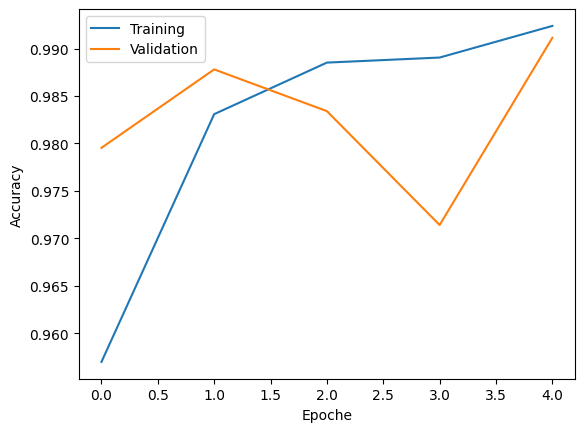

In [7]:
import matplotlib.pyplot as plt
plt.plot(hist.history['accuracy'], label='Training')
plt.plot(hist.history['val_accuracy'], label='Validation')
plt.xlabel("Epoche")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

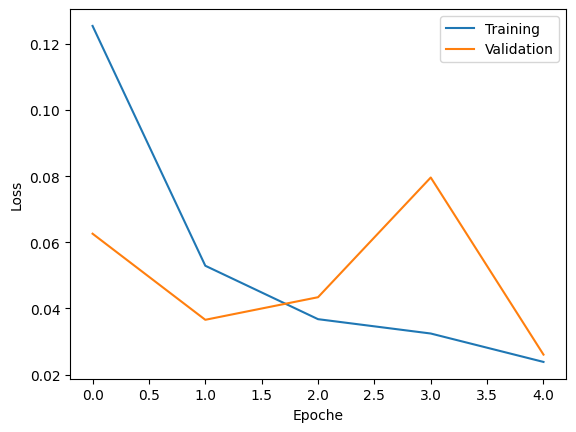

In [8]:
plt.plot(hist.history['loss'], label='Training')
plt.plot(hist.history['val_loss'], label='Validation')
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.legend()
plt.show()

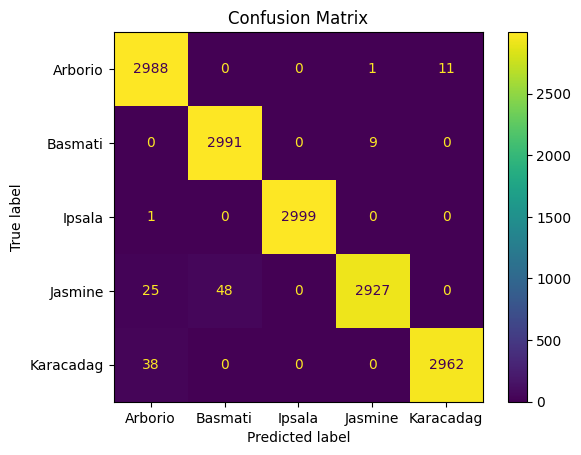

In [9]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predizioni sul test set
predizioni = modello.predict(X_test, verbose=0)

# Classe predetta
y_pred = np.argmax(predizioni, axis=1)

# Matrice di confusione
cm = confusion_matrix(Y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classi
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

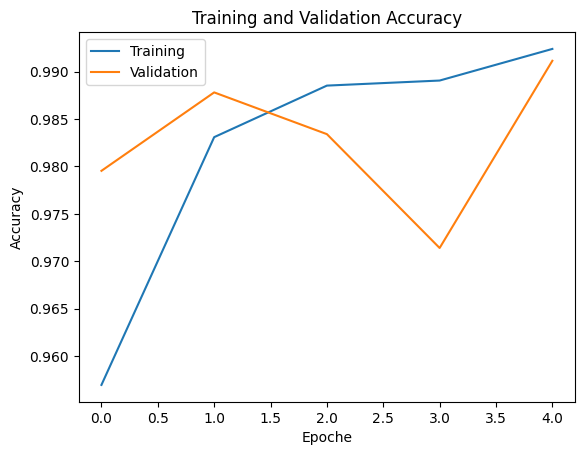

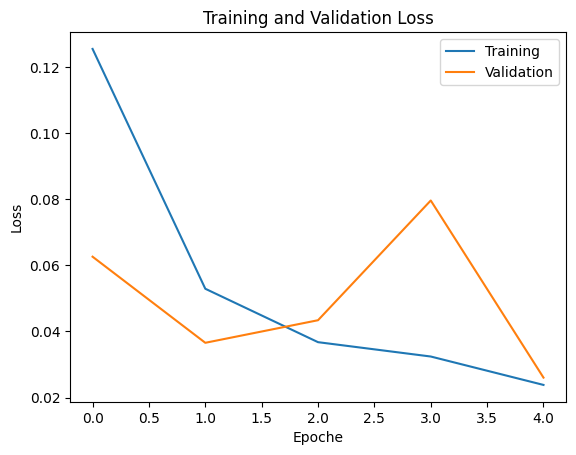

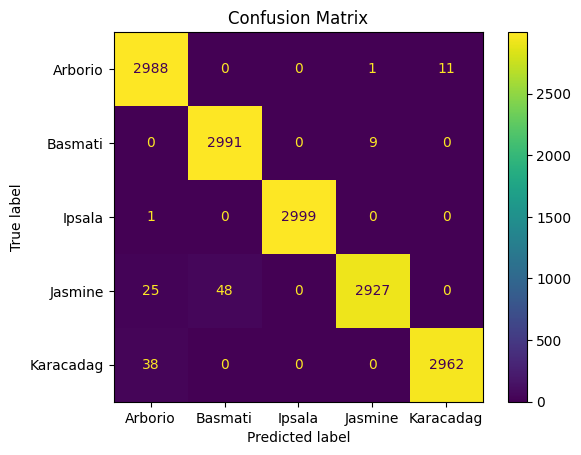

In [10]:
import os
import matplotlib.pyplot as plt

# Crea la cartella per le immagini
os.makedirs("/workspace/images", exist_ok=True)

# Accuracy
plt.figure()
plt.plot(hist.history['accuracy'], label='Training')
plt.plot(hist.history['val_accuracy'], label='Validation')
plt.xlabel("Epoche")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training and Validation Accuracy")
plt.savefig("/workspace/images/accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

# Loss
plt.figure()
plt.plot(hist.history['loss'], label='Training')
plt.plot(hist.history['val_loss'], label='Validation')
plt.xlabel("Epoche")
plt.ylabel("Loss")
plt.legend()
plt.title("Training and Validation Loss")
plt.savefig("/workspace/images/loss.png", dpi=150, bbox_inches="tight")
plt.show()

# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

predizioni = modello.predict(X_test, verbose=0)
y_pred = np.argmax(predizioni, axis=1)

cm = confusion_matrix(Y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classi
)

disp.plot()
plt.title("Confusion Matrix")
plt.savefig("/workspace/images/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()